# 🏆 Modélisation et Optimisation des Retards TGV

Ce notebook a pour but d'entraîner et de comparer trois algorithmes de Machine Learning pour prédire le taux de retard à l'arrivée. Étant donné la nature chronologique de nos données, nous utiliserons une validation croisée temporelle (`TimeSeriesSplit`).

**Objectifs :**
1. Définir une stratégie d'évaluation robuste (Time Series CV).
2. Entraîner et optimiser 3 modèles (Ridge, Random Forest, XGBoost).
3. Visualiser les performances et sélectionner le meilleur candidat.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Utilisation de GradientBoostingRegressor comme alternative si xgboost n'est pas installé
from sklearn.ensemble import GradientBoostingRegressor

# --- CONFIGURATION ---
sns.set_theme(style="whitegrid")
base_path = Path(r'C:/Users/Utilisateur/Documents/Albert School/B2/SEMESTRE 2/Achieving a ML Proof of Concept/ml-poc-project')
data_path = base_path / 'data' / 'processed_dataset.csv'
models_dir = base_path / 'models'
models_dir.mkdir(exist_ok=True)

print("Bibliothèques chargées.")

Bibliothèques chargées.


## 1. Chargement et Préparation Temporelle

On isole l'année 2023 comme test final (ce que le modèle n'a jamais vu, ni pendant l'entraînement, ni pendant l'optimisation).

In [2]:
df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date') # Tri obligatoire pour les séries temporelles

# --- 🛠️ CORRECTION DE L'ERREUR NAN ---
print(f"Valeurs manquantes détectées : {df.isna().sum().sum()}")
# On remplace tous les petits "trous" restants par 0 (le plus neutre pour nos calculs)
df = df.fillna(0)
print(f"Valeurs manquantes après correction : {df.isna().sum().sum()}")
# --------------------------------------

# Split temporel strict
train_val = df[df['Date'].dt.year < 2023]
test = df[df['Date'].dt.year == 2023]

print(f"Période d'entraînement : {train_val['Date'].min().date()} à {train_val['Date'].max().date()}")
print(f"Période de test final : {test['Date'].min().date()} à {test['Date'].max().date()}")

# Séparation Features (X) / Cible (y)
cols_to_drop = ['Date', 'target', 'id_ligne', 'ligne_txt', "taux_retard"]  # On retire les colonnes non pertinentes ou redondantes
X_train = train_val.drop(columns=[c for c in cols_to_drop if c in train_val.columns], errors='ignore')
y_train = train_val['target']

X_test = test.drop(columns=[c for c in cols_to_drop if c in test.columns], errors='ignore')
y_test = test['target']

print(f"Nombre de features envoyées au modèle : {X_train.shape[1]}")

Valeurs manquantes détectées : 73
Valeurs manquantes après correction : 0
Période d'entraînement : 2018-04-01 à 2022-12-01
Période de test final : 2023-01-01 à 2023-12-01
Nombre de features envoyées au modèle : 151


## 2. Définition de la Validation Croisée Temporelle
Au lieu de `KFold`, on utilise `TimeSeriesSplit` avec 5 itérations. Le modèle apprend sur le passé pour prédire le futur immédiat.

In [3]:
tscv = TimeSeriesSplit(n_splits=5)
results_dict = {} # Pour stocker les métriques

## 3. Entraînement et Optimisation des Modèles
### Modèle 1 : Ridge Regression (Modèle de référence)
Un modèle linéaire régularisé. Il est rapide et donne une bonne base.

In [4]:
print("⏳ Optimisation Ridge en cours...")
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

params_ridge = {'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
grid_ridge = GridSearchCV(pipe_ridge, params_ridge, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_ridge.fit(X_train, y_train)

best_ridge = grid_ridge.best_estimator_
print(f"✅ Meilleur paramètre Ridge : {grid_ridge.best_params_}")

⏳ Optimisation Ridge en cours...
✅ Meilleur paramètre Ridge : {'model__alpha': 1.0}


### Modèle 2 : Random Forest
Un ensemble d'arbres de décision. Parfait pour capter les effets de seuil (ex: "si la densité dépasse X, le retard explose").

In [5]:
print("⏳ Optimisation Random Forest en cours (peut prendre quelques minutes)...")
rf = RandomForestRegressor(random_state=42)

params_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, params_rf, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print(f"✅ Meilleurs paramètres RF : {grid_rf.best_params_}")

⏳ Optimisation Random Forest en cours (peut prendre quelques minutes)...
✅ Meilleurs paramètres RF : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}


### Modèle 3 : Gradient Boosting (XGBoost / GBR)
Une approche où chaque arbre corrige les erreurs du précédent. Très performant sur les données tabulaires complexes.

In [6]:
print("⏳ Optimisation Gradient Boosting en cours...")
gb = GradientBoostingRegressor(random_state=42)

params_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(gb, params_gb, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
print(f"✅ Meilleurs paramètres GB : {grid_gb.best_params_}")

⏳ Optimisation Gradient Boosting en cours...
✅ Meilleurs paramètres GB : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}


## 4. Évaluation sur l'année de Test (2023)
Nous allons mesurer la MAE (Erreur Absolue Moyenne) : de combien de points de pourcentage le modèle se trompe-t-il en moyenne ?

In [7]:
models_dict = {
    'Ridge': best_ridge,
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb
}

for name, model in models_dict.items():
    y_pred = model.predict(X_test)
    # Remettre à 0 les prédictions négatives (un retard ne peut pas être négatif)
    y_pred = np.maximum(0, y_pred)
    
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results_dict[name] = {'MAE': mae, 'R2': r2}
    
    # Sauvegarde du modèle
    joblib.dump(model, models_dir / f"{name.lower().replace(' ', '_')}_model.joblib")

# Création d'un DataFrame de résultats
df_results = pd.DataFrame(results_dict).T
df_results['MAE (%)'] = df_results['MAE'] * 100
print("\n🏆 --- RÉSULTATS DE L'ÉVALUATION --- 🏆")
print(df_results[['MAE (%)', 'R2']].sort_values(by='MAE (%)'))


🏆 --- RÉSULTATS DE L'ÉVALUATION --- 🏆
                    MAE (%)        R2
Gradient Boosting  0.913499  0.953839
Random Forest      1.237649  0.920442
Ridge              1.992692  0.778869


In [8]:
model

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

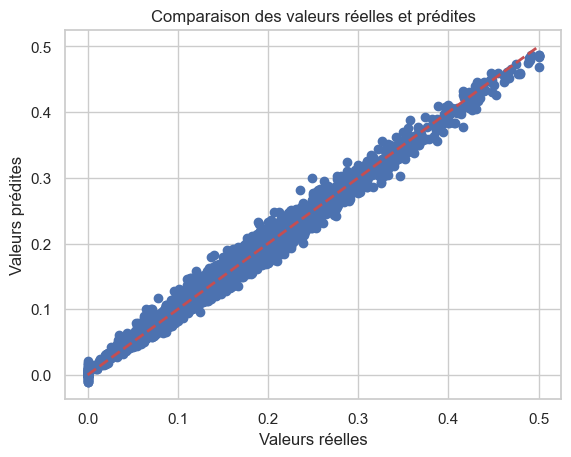

In [9]:
y_pred = model.predict(X_train)

plt.scatter(y_train, y_pred)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Comparaison des valeurs réelles et prédites")
plt.show()

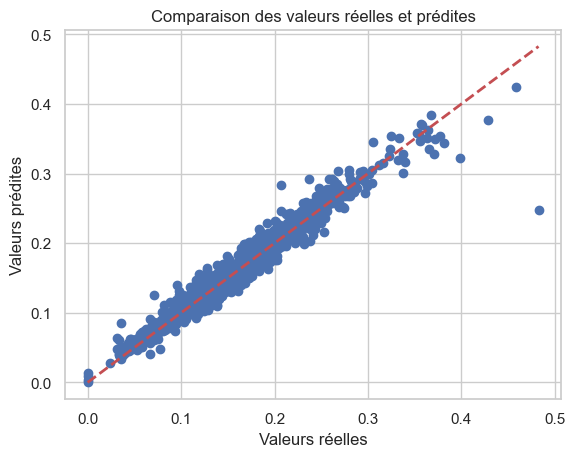

In [10]:
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
# premiere adjacente 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Comparaison des valeurs réelles et prédites")
plt.show()

In [11]:
len(X_train), len(X_test)

(6997, 1443)

In [12]:
X_train.shape, X_test.shape

((6997, 151), (1443, 151))

Text(0.5, 0, 'Coefficient de la feature')

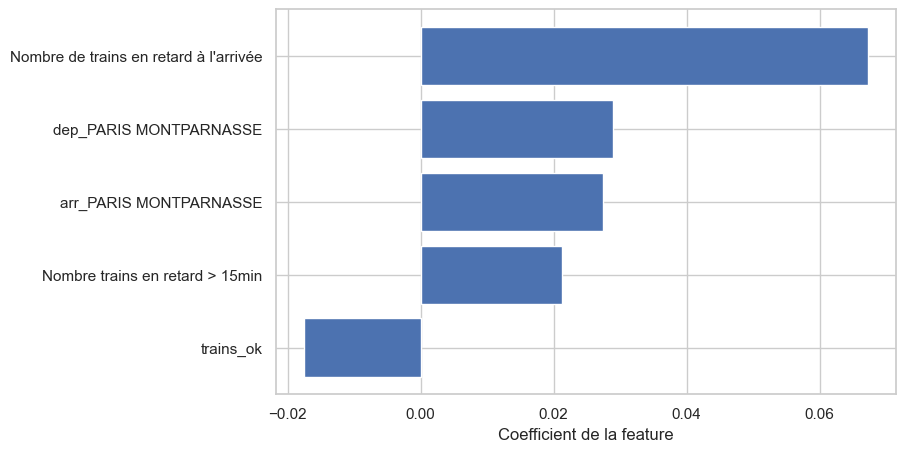

In [13]:
# plot parameters as barh

params= best_ridge.named_steps['model'].coef_
features = X_train.columns

# top 5
top_5_idx = np.argsort(np.abs(params))[-5:]
top_5_params = params[top_5_idx]

top_5_features = features[top_5_idx]
plt.figure(figsize=(8, 5))
plt.barh(top_5_features, top_5_params)
plt.xlabel("Coefficient de la feature")

### 1. Analyse des Résidus (Histogramme et Nuage de points)
Ce code permet de voir si vos erreurs sont normalement distribuées (cloche de Gauss) ou si le modèle a un biais systématique (s'il sous-estime toujours les gros retards, par exemple).

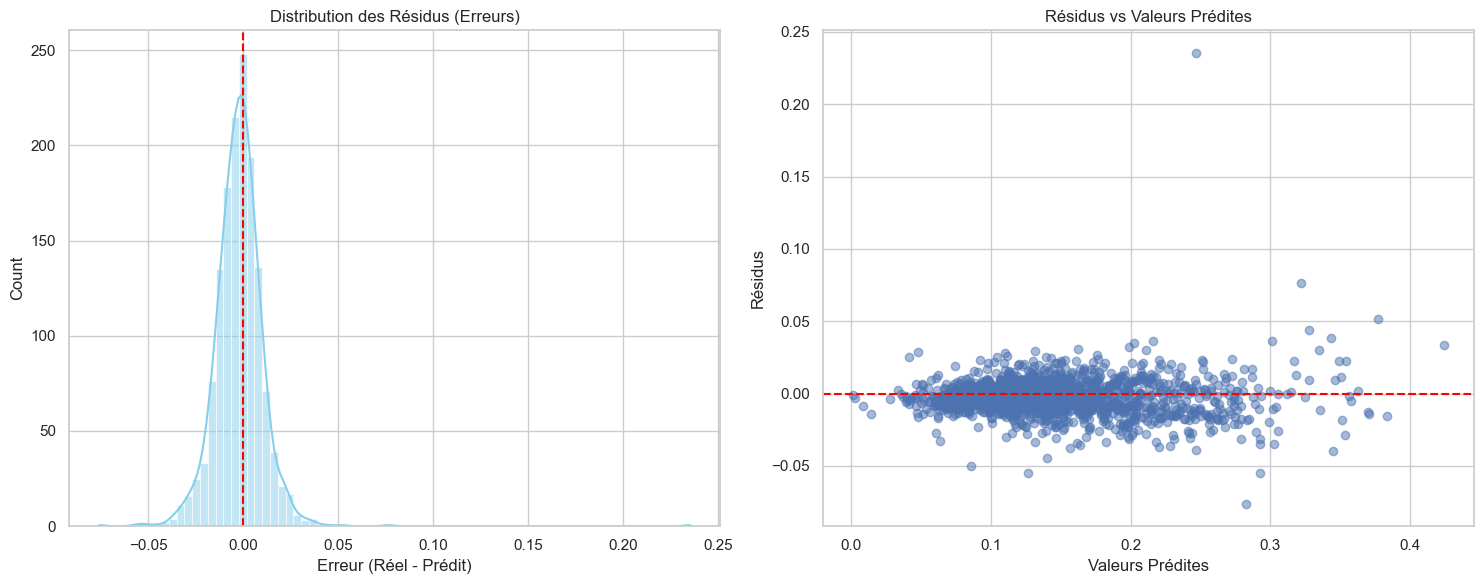

🔍 Top 5 des erreurs les plus importantes :


,Date,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,...,lag_2,lag_3,month,month_sin,month_cos,surcharge_absolue,surcharge_relative,densite_trafic,pred,erreur_abs
1835,2023-11-01,228,152,9,29,21.048276,4.059674,69,31.596377,9.981002,...,0.160714,0.160920,11,-0.500000,8.660254e-01,152,1.063557,0.666667,0.247048,0.235470
2651,2023-04-01,74,159,6,73,6.367352,3.410211,61,16.125137,6.408685,...,0.206061,0.184358,4,0.866025,-5.000000e-01,159,0.946898,2.148649,0.322097,0.076596
5009,2023-03-01,242,32,3,22,2.941667,1.863095,6,29.322222,9.256548,...,0.164384,0.210084,3,1.000000,6.123234e-17,32,0.227152,0.132231,0.282987,0.076090
6828,2023-09-01,195,140,1,113,6.974041,4.632971,33,30.030303,12.122585,...,0.304965,0.282051,9,-1.000000,-1.836970e-16,140,1.146888,0.717949,0.292560,0.055150
1099,2023-01-01,295,31,3,1,4.000000,0.180357,2,218.691667,15.760119,...,0.130435,0.068966,1,0.500000,8.660254e-01,31,1.221847,0.105085,0.126275,0.054846


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# On utilise le meilleur modèle (ex: Gradient Boosting) sur le jeu de test
model = best_gb 
y_pred = np.maximum(0, model.predict(X_test))
residuals = y_test - y_pred

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Graphique A : Distribution des résidus
sns.histplot(residuals, kde=True, ax=ax[0], color='skyblue')
ax[0].axvline(0, color='red', linestyle='--')
ax[0].set_title('Distribution des Résidus (Erreurs)')
ax[0].set_xlabel('Erreur (Réel - Prédit)')

# Graphique B : Résidus vs Valeurs Prédites (Chercher l'hétéroscédasticité)
ax[1].scatter(y_pred, residuals, alpha=0.5)
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('Résidus vs Valeurs Prédites')
ax[1].set_xlabel('Valeurs Prédites')
ax[1].set_ylabel('Résidus')

plt.tight_layout()
plt.show()

# Petit bonus : Afficher les 5 plus grosses erreurs pour enquête
test_with_errors = test.copy()
test_with_errors['pred'] = y_pred
test_with_errors['erreur_abs'] = np.abs(residuals)
print("🔍 Top 5 des erreurs les plus importantes :")
display(test_with_errors.sort_values('erreur_abs', ascending=False).head(5))

### 2. Variance de la MAE sur les K-Folds (Stabilité)
Ce code va ré-exécuter la validation croisée temporelle (TimeSeriesSplit) et enregistrer le score de chaque "fold". Si la MAE varie énormément d'un fold à l'autre, cela signifie que votre modèle est instable suivant les périodes.

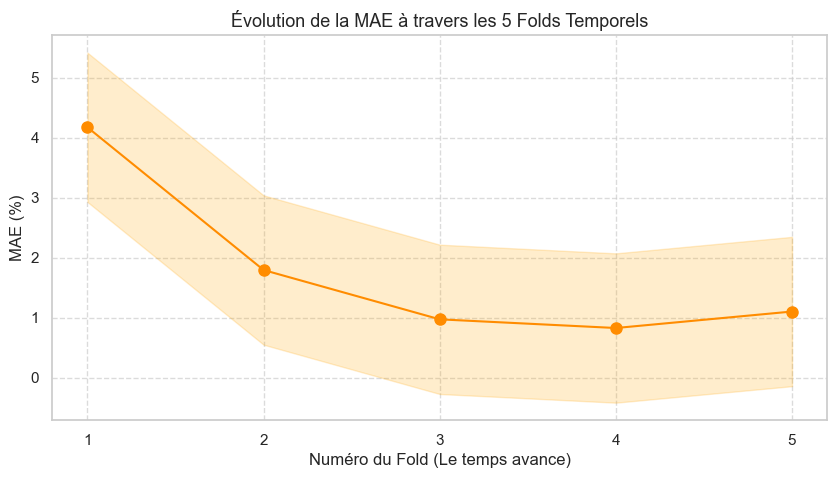

📊 MAE Moyenne sur les folds : 1.77%
📉 Écart-type (Instabilité) : 1.24%


In [15]:
from sklearn.model_selection import cross_val_score

# On définit le modèle à tester
model_to_test = model

# Rappel : on utilise TimeSeriesSplit pour respecter la chronologie
tscv = TimeSeriesSplit(n_splits=5)

# Calcul des scores (MAE) pour chaque fold
# Note : sklearn utilise des scores négatifs pour la MAE, on multiplie par -1
cv_scores = cross_val_score(model_to_test, X_train, y_train, 
                            cv=tscv, scoring='neg_mean_absolute_error')
cv_mae = -cv_scores * 100 # Conversion en %

# Visualisation de la variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), cv_mae, marker='o', linestyle='-', color='darkorange', markersize=8)
plt.fill_between(range(1, 6), cv_mae - np.std(cv_mae), cv_mae + np.std(cv_mae), alpha=0.2, color='orange')

plt.title('Évolution de la MAE à travers les 5 Folds Temporels', fontsize=13)
plt.xlabel('Numéro du Fold (Le temps avance)')
plt.ylabel('MAE (%)')
plt.xticks(range(1, 6))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"📊 MAE Moyenne sur les folds : {cv_mae.mean():.2f}%")
print(f"📉 Écart-type (Instabilité) : {cv_mae.std():.2f}%")

## 5. Visualisation des Performances
Comparons l'erreur moyenne de chaque algorithme.

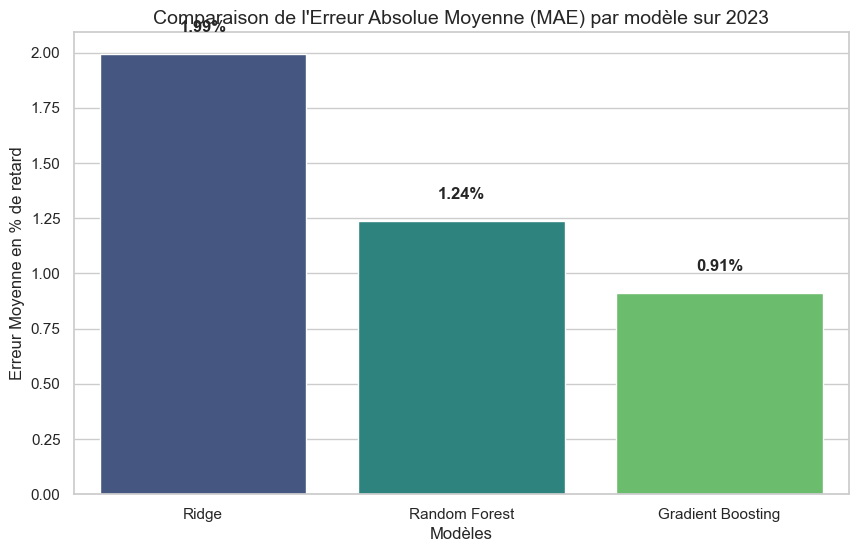

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_results.index, y='MAE (%)', data=df_results, hue=df_results.index, palette='viridis', legend=False)
plt.title('Comparaison de l\'Erreur Absolue Moyenne (MAE) par modèle sur 2023', fontsize=14)
plt.ylabel('Erreur Moyenne en % de retard')
plt.xlabel('Modèles')
for i, v in enumerate(df_results['MAE (%)']):
    plt.text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

In [17]:
import os
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.compose import TransformedTargetRegressor

# 1. ON RECRÉE UN X_TRAIN PARFAITEMENT PROPRE ET ALIGNÉ AVEC PRODUCTION
base_path = Path(r'C:/Users/Utilisateur/Documents/Albert School/B2/SEMESTRE 2/Achieving a ML Proof of Concept/ml-poc-project')
df_notebook = pd.read_csv(base_path / 'data' / 'processed_dataset.csv')
df_notebook['Date'] = pd.to_datetime(df_notebook['Date'])
df_notebook = df_notebook.sort_values(by='Date').fillna(0)

# Découpage train
train_val_notebook = df_notebook[df_notebook['Date'].dt.year < 2023].copy()

# Injection de l'Ancre Historique
ligne_baseline_nb = train_val_notebook.groupby('id_ligne')['target'].mean().to_dict()
train_val_notebook['baseline_historique_ligne'] = train_val_notebook['id_ligne'].map(ligne_baseline_nb).fillna(0)

# Filtre Anti-Triche Strict (on vire le leakage)
colonnes_triche_nb = [col for col in train_val_notebook.columns if ('retard' in col.lower() or 'annul' in col.lower()) and 'lag' not in col.lower()]
cols_to_drop_nb = ['Date', 'target', 'id_ligne', 'ligne_txt', 'trains_ok'] + colonnes_triche_nb

# Nos matrices d'entraînement enfin parfaites
X_train_clean = train_val_notebook.drop(columns=[c for c in cols_to_drop_nb if c in train_val_notebook.columns], errors='ignore')
y_train_clean = train_val_notebook['target']


# 2. CONFIGURATION ET FIT DES MODÈLES AVEC LA SÉCURITÉ LOGARITHMIQUE
target_models_dir = r"C:\Users\Utilisateur\Documents\Albert School\B2\SEMESTRE 2\Achieving a ML Proof of Concept\ml-poc-project\models"
os.makedirs(target_models_dir, exist_ok=True)

# (Ajuste les noms grid_ridge, grid_rf, grid_gb si tu as nommé tes GridSearchCV autrement)
modele_export_ridge = TransformedTargetRegressor(regressor=grid_ridge.best_estimator_, func=np.log1p, inverse_func=np.expm1)
modele_export_rf = TransformedTargetRegressor(regressor=grid_rf.best_estimator_, func=np.log1p, inverse_func=np.expm1)
modele_export_gb = TransformedTargetRegressor(regressor=grid_gb.best_estimator_, func=np.log1p, inverse_func=np.expm1)

print("⏳ Ré-entraînement des modèles sur les bonnes features...")
modele_export_ridge.fit(X_train_clean, y_train_clean)
modele_export_rf.fit(X_train_clean, y_train_clean)
modele_export_gb.fit(X_train_clean, y_train_clean)


# 3. SAUVEGARDE DES FICHIERS .JOBLIB CONFORMES
joblib.dump(modele_export_ridge, os.path.join(target_models_dir, "ridge_expert_model.joblib"))
joblib.dump(modele_export_rf, os.path.join(target_models_dir, "random_forest_expert_model.joblib"))
joblib.dump(modele_export_gb, os.path.join(target_models_dir, "gradient_boosting_expert_model.joblib"))

print("🎯 Terminé ! Modèles ré-exportés avec succès et 100% alignés avec le pipeline du projet !")

⏳ Ré-entraînement des modèles sur les bonnes features...
🎯 Terminé ! Modèles ré-exportés avec succès et 100% alignés avec le pipeline du projet !


In [18]:
import os
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.compose import TransformedTargetRegressor

# 1. Reconstruction du X_train clean adapté à la structure OHE
base_path = Path(r'C:/Users/Utilisateur/Documents/Albert School/B2/SEMESTRE 2/Achieving a ML Proof of Concept/ml-poc-project')
df_notebook = pd.read_csv(base_path / 'data' / 'processed_dataset.csv')
df_notebook['Date'] = pd.to_datetime(df_notebook['Date'])
df_notebook = df_notebook.sort_values(by='Date').fillna(0)

cols_depart = [c for c in df_notebook.columns if c.startswith("Gare de départ_")]
cols_arrivee = [c for c in df_notebook.columns if c.startswith("Gare d'arrivée_") or c.startswith("Gare d’arrivée_")]

if cols_depart and cols_arrivee:
    df_notebook['id_ligne_temp'] = df_notebook[cols_depart].idxmax(axis=1) + " ➔ " + df_notebook[cols_arrivee].idxmax(axis=1)
else:
    df_notebook['id_ligne_temp'] = "Axe_Unique"

train_val_notebook = df_notebook[df_notebook['Date'].dt.year < 2023].copy()

ligne_baseline_nb = train_val_notebook.groupby('id_ligne_temp')['target'].mean().to_dict()
train_val_notebook['baseline_historique_ligne'] = train_val_notebook['id_ligne_temp'].map(ligne_baseline_nb).fillna(0)

colonnes_triche_nb = [col for col in train_val_notebook.columns if ('retard' in col.lower() or 'annul' in col.lower()) and 'lag' not in col.lower()]
cols_to_drop_nb = ['Date', 'target', 'id_ligne', 'id_ligne_temp', 'ligne_txt', 'trains_ok'] + colonnes_triche_nb

X_train_clean = train_val_notebook.drop(columns=[c for c in cols_to_drop_nb if c in train_val_notebook.columns], errors='ignore')
y_train_clean = train_val_notebook['target']

# 2. Entraînement et Export
target_models_dir = r"C:\Users\Utilisateur\Documents\Albert School\B2\SEMESTRE 2\Achieving a ML Proof of Concept\ml-poc-project\models"
os.makedirs(target_models_dir, exist_ok=True)

modele_export_ridge = TransformedTargetRegressor(regressor=grid_ridge.best_estimator_, func=np.log1p, inverse_func=np.expm1)
modele_export_rf = TransformedTargetRegressor(regressor=grid_rf.best_estimator_, func=np.log1p, inverse_func=np.expm1)
modele_export_gb = TransformedTargetRegressor(regressor=grid_gb.best_estimator_, func=np.log1p, inverse_func=np.expm1)

modele_export_ridge.fit(X_train_clean, y_train_clean)
modele_export_rf.fit(X_train_clean, y_train_clean)
modele_export_gb.fit(X_train_clean, y_train_clean)

joblib.dump(modele_export_ridge, os.path.join(target_models_dir, "ridge_expert_model.joblib"))
joblib.dump(modele_export_rf, os.path.join(target_models_dir, "random_forest_expert_model.joblib"))
joblib.dump(modele_export_gb, os.path.join(target_models_dir, "gradient_boosting_expert_model.joblib"))
print("🎯 Modèles ré-exportés avec succès et 100% compatibles OHE !")

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_22968\2281245429.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_notebook['id_ligne_temp'] = "Axe_Unique"


🎯 Modèles ré-exportés avec succès et 100% compatibles OHE !
